# 05 · Hotspots of vegetation loss (Getis-Ord Gi*)

**Question:** *Where* along Section 1 was vegetation loss concentrated, and did that pattern change when construction started?

**Mirrors script:** `python/06_hotspots.py`.
**Inputs:** `data/rasters/LC_DS{2020,2023,2024,2025,2026}_S1.tif`, `data/vectors/segment_zones_all.shp`.
**Outputs:** `results/hotspot_summary.csv`, `results/vectors/hotspots_S1_5ha.shp` (the layer mapped in Figure 8).

### The idea
A hotspot is a place where **high values cluster**: not just one hexagon with heavy loss, but a hexagon whose *neighbourhood* also lost a lot, more than chance would produce. If construction drove the loss, hotspots should move onto the road once work began.

In [1]:
# --- Setup: find the repository folders (works from notebooks/ or the repo root) ---
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'python'))
from paths import DATA, VEC, RAS, TAB, VAL, RES, ZONES, CRS   # shared folder locations
warnings.filterwarnings('ignore')

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
print('Repository root found:', ROOT.name)

Repository root found: lagos-calabar-s1-vegetation-loss


## 1. Persistent loss

The change map over-maps loss (only 25% of mapped loss was confirmed, notebook 02), mostly because of one-year misclassifications. So loss here must **persist for two consecutive years**:

| Period | Vegetation at start | Counted as lost if non-vegetated in |
|---|---|---|
| Before construction | DS2020 | **both** DS2023 and DS2024 |
| During construction | DS2024 | **both** DS2025 and DS2026 |

In [2]:
import geopandas as gpd, rasterio
from rasterio import features
from shapely.geometry import Polygon
from libpysal.weights import DistanceBand
from esda.getisord import G_Local
from statsmodels.stats.multitest import multipletests
import contextlib, io
np.random.seed(2026)

lc = {}
for y in [2020, 2023, 2024, 2025, 2026]:
    with rasterio.open(RAS / f'LC_DS{y}_S1.tif') as r:
        lc[y] = r.read(1); T = r.transform; shape = r.shape
veg = {y: lc[y] == 1 for y in lc}
nonveg = {y: (lc[y] >= 2) & (lc[y] <= 5) for y in lc}
valid = np.logical_and.reduce([lc[y] > 0 for y in lc])
pre_start = veg[2020] & valid; pre_loss = pre_start & nonveg[2023] & nonveg[2024]
con_start = veg[2024] & valid; con_loss = con_start & nonveg[2025] & nonveg[2026]
for name, s_, l_ in [('before', pre_start, pre_loss), ('during', con_start, con_loss)]:
    print(f'{name:6s}: start vegetation {s_.sum()*0.01:8,.0f} ha, persistent loss {l_.sum()*0.01:6,.0f} ha')

before: start vegetation   13,580 ha, persistent loss  3,373 ha
during: start vegetation   10,643 ha, persistent loss    556 ha


## 2. A hexagon grid over the corridor

Hexagons are used because all six neighbours are the same distance away, unlike squares. The grid covers the Section 1 footprint and bands (to 5 km). Hexagons less than half inside the corridor are dropped. The paper uses **5 ha hexagons** (side ≈ 139 m); 2 ha and 10 ha are tested below.

In [3]:
z = gpd.read_file(VEC / 'segment_zones_all.shp').to_crs(32631)
s1 = z[z.side == 'S1']
area_geom = s1.union_all()
foot = s1[s1.zone == 'F'].union_all()

def hexgrid(bounds, area_ha):
    a = np.sqrt(2 * area_ha * 1e4 / (3 * np.sqrt(3)))          # side length (m) for the requested area
    w, h = 2 * a, np.sqrt(3) * a
    x0, y0, x1, y1 = bounds
    hexes, col, x = [], 0, x0
    while x < x1 + w:
        y = y0 - (h / 2 if col % 2 else 0)
        while y < y1 + h:
            hexes.append(Polygon([(x + a * np.cos(t), y + a * np.sin(t)) for t in np.radians(range(0, 360, 60))]))
            y += h
        x += 1.5 * a; col += 1
    return gpd.GeoDataFrame(geometry=hexes, crs=32631)

## 3. Getis-Ord Gi*

For each hexagon *i* with at least 1 ha of vegetation at the start of the period, $x_i$ = % of that vegetation lost. With binary weights $w_{ij} = 1$ for hexagons within the distance band (500 m, including *i* itself, hence the *star*):

$$G_i^* = \frac{\sum_j w_{ij} x_j}{\sum_j x_j}$$

The observed value is compared with 999 random permutations of the other hexagons' values, giving a z-score and a pseudo p-value. Because thousands of hexagons are tested at once, p-values are corrected with the **Benjamini–Hochberg false discovery rate** (q < 0.05). Hexagons with z > 0 and significant are **hot spots**; z < 0 and significant are **cold spots**.

In [4]:
def run(area_ha, band):
    g = hexgrid(area_geom.bounds, area_ha)
    g = g[g.intersects(area_geom)].copy()
    g['geometry'] = g.geometry.intersection(area_geom)
    g = g[g.area >= 0.5 * area_ha * 1e4].reset_index(drop=True)
    idx = features.rasterize(((geom, i + 1) for i, geom in enumerate(g.geometry)),
                             out_shape=shape, transform=T, fill=0, dtype='int32')
    n = len(g) + 1
    cnt = lambda m: np.bincount(idx[m].ravel(), minlength=n)[1:] * 0.01          # hectares per hexagon
    g['pre_veg_ha'], g['pre_loss_ha'] = cnt(pre_start), cnt(pre_loss)
    g['con_veg_ha'], g['con_loss_ha'] = cnt(con_start), cnt(con_loss)
    g['dist_road_m'] = g.geometry.centroid.distance(foot)
    for p in ['pre', 'con']:
        ok = g[f'{p}_veg_ha'] >= 1.0
        g[f'{p}_pct'] = np.where(ok, 100 * g[f'{p}_loss_ha'] / g[f'{p}_veg_ha'].clip(lower=1e-9), np.nan)
        sub = g[ok]
        pts = np.column_stack([sub.geometry.centroid.x, sub.geometry.centroid.y])
        with contextlib.redirect_stdout(io.StringIO()):      # hide libpysal's 'island' messages
            W = DistanceBand(pts, threshold=band, binary=True, silence_warnings=True)
            gi = G_Local(sub[f'{p}_pct'].values, W, star=True, permutations=999, seed=2026)
        q = multipletests(gi.p_sim, alpha=0.05, method='fdr_bh')[0]
        g.loc[ok, f'{p}_giz'] = gi.Zs
        g.loc[ok, f'{p}_p'] = gi.p_sim
        g.loc[ok, f'{p}_cls'] = np.where(q & (gi.Zs > 0), 'Hot spot', np.where(q & (gi.Zs < 0), 'Cold spot', 'Not significant'))
        g[f'{p}_cls'] = g[f'{p}_cls'].fillna('Too little vegetation')
    return g

g5 = run(5, 500)
g5.to_file(RES / 'vectors' / 'hotspots_S1_5ha.shp')
pd.crosstab(g5.pre_cls, g5.con_cls, margins=True).rename_axis(index='before ↓ / during →')

con_cls,Cold spot,Hot spot,Not significant,Too little vegetation,All
before ↓ / during →,,,,,
Cold spot,488,83,620,11,1202
Hot spot,2,15,242,480,739
Not significant,50,74,926,249,1299
Too little vegetation,4,13,66,7837,7920
All,544,185,1854,8577,11160


## 4. Maps: before vs during construction

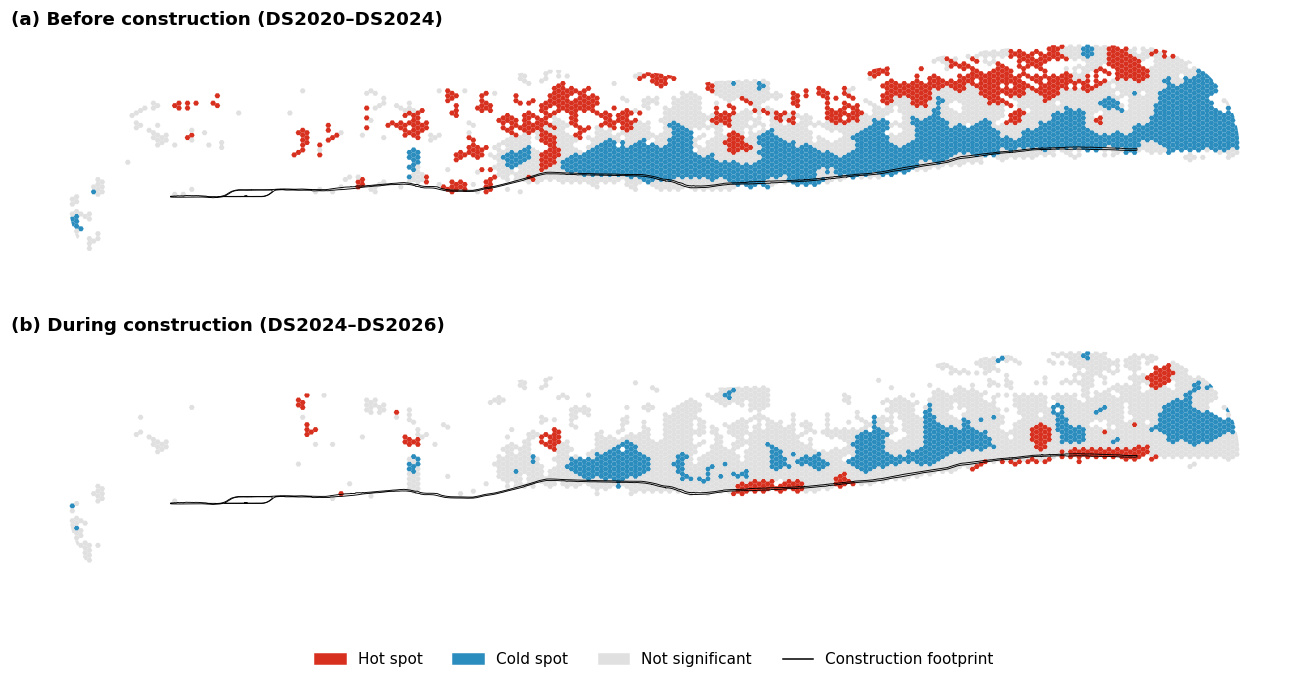

In [5]:
cols = {'Hot spot': '#D7301F', 'Cold spot': '#2B8CBE', 'Not significant': '#E0E0E0', 'Too little vegetation': '#FFFFFF'}
fpg = gpd.GeoSeries([foot], crs=32631)
fig, axs = plt.subplots(2, 1, figsize=(12, 6.5))
for ax, p, title in zip(axs, ['pre', 'con'], ['(a) Before construction (DS2020–DS2024)', '(b) During construction (DS2024–DS2026)']):
    for c, col in cols.items():
        sub = g5[g5[f'{p}_cls'] == c]
        if len(sub) and c != 'Too little vegetation':
            sub.plot(ax=ax, color=col, linewidth=0)
    fpg.boundary.plot(ax=ax, color='black', linewidth=0.6)
    ax.set_title(title, loc='left', fontweight='bold'); ax.set_axis_off()
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
fig.legend([Patch(color=cols[c]) for c in ['Hot spot', 'Cold spot', 'Not significant']] + [Line2D([], [], color='black', lw=1)],
           ['Hot spot', 'Cold spot', 'Not significant', 'Construction footprint'], loc='lower center', ncol=4, frameon=False)
plt.tight_layout(rect=(0, 0.05, 1, 1)); plt.show()

## 5. How far from the road are the hotspots?

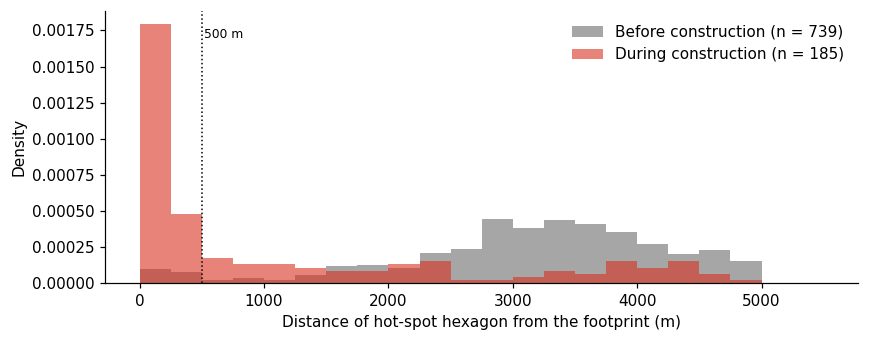

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.2))
bins = np.arange(0, 5600, 250)
for p, col, lab in [('pre', '#6B6B6B', 'Before construction'), ('con', '#D7301F', 'During construction')]:
    hot = g5[g5[f'{p}_cls'] == 'Hot spot']
    ax.hist(hot.dist_road_m, bins, color=col, alpha=0.6, density=True, label=f'{lab} (n = {len(hot)})')
ax.axvline(500, color='black', ls=':', lw=1); ax.text(520, ax.get_ylim()[1] * 0.9, '500 m', fontsize=8)
ax.set_xlabel('Distance of hot-spot hexagon from the footprint (m)'); ax.set_ylabel('Density'); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 6. Sensitivity: does the result depend on the grid?

Hexagon size and neighbourhood distance are arbitrary choices, so the analysis is repeated for 2, 5 and 10 ha hexagons and 500 m and 1,000 m bands (about a minute). The key number is the share of hot spots within 500 m of the footprint, compared with the share of *all* analysed hexagons within 500 m (what chance alone would give).

In [7]:
def describe(g, area_ha, band):
    out = []
    for p, lab in [('pre', 'Before construction (2020→2024)'), ('con', 'Construction (2024→2026)')]:
        hot = g[g[f'{p}_cls'] == 'Hot spot']
        out.append(dict(hex_ha=area_ha, band_m=band, period=lab, hexagons=int(g[f'{p}_pct'].notna().sum()),
                        hot=len(hot), cold=int((g[f'{p}_cls'] == 'Cold spot').sum()),
                        hot_within_500m_pct=100 * (hot.dist_road_m <= 500).mean() if len(hot) else np.nan,
                        all_within_500m_pct=100 * (g[g[f'{p}_pct'].notna()].dist_road_m <= 500).mean(),
                        median_hot_dist_m=hot.dist_road_m.median() if len(hot) else np.nan,
                        loss_ha=g[f'{p}_loss_ha'].sum()))
    return out

rows = []
for area_ha in [2, 5, 10]:
    for band in [500, 1000]:
        rows += describe(g5 if (area_ha, band) == (5, 500) else run(area_ha, band), area_ha, band)
res = pd.DataFrame(rows); res.to_csv(RES / 'hotspot_summary.csv', index=False)
res.round(1)

,hex_ha,band_m,period,hexagons,hot,cold,hot_within_500m_pct,all_within_500m_pct,median_hot_dist_m,loss_ha
0,2,500,Before construction (2020→2024),5851,1239,2680,8.2,19.4,2965.3,2934.7
1,2,500,Construction (2024→2026),4576,484,1475,66.1,20.7,209.4,502.0
2,2,1000,Before construction (2020→2024),5851,1647,3130,5.6,19.4,3040.5,2934.7
3,2,1000,Construction (2024→2026),4576,770,2159,51.2,20.7,472.4,502.0
4,5,500,Before construction (2020→2024),3240,739,1202,4.3,17.5,3283.6,2929.9
5,5,500,Construction (2024→2026),2583,185,544,56.8,18.4,291.5,501.0
6,5,1000,Before construction (2020→2024),3240,999,1553,4.9,17.5,3206.0,2929.9
7,5,1000,Construction (2024→2026),2583,341,818,47.8,18.4,539.4,501.0
8,10,500,Before construction (2020→2024),1951,281,422,4.3,16.8,3521.5,2925.2
9,10,500,Construction (2024→2026),1575,53,186,56.6,18.0,257.8,501.5


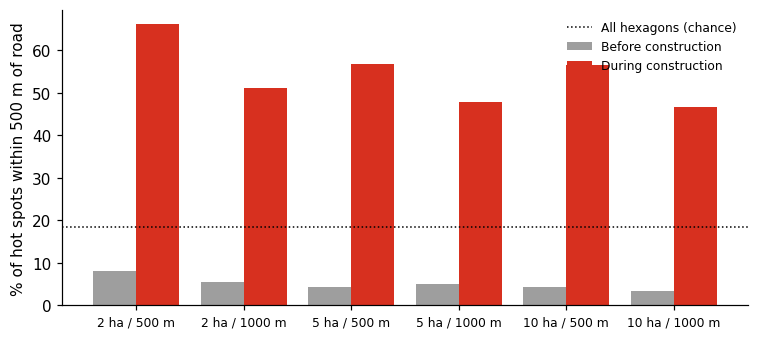

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.2))
lab = [f'{h} ha / {b} m' for h, b in zip(res.hex_ha[::2], res.band_m[::2])]
x = np.arange(len(lab))
ax.bar(x - 0.2, res[res.period.str.startswith('Before')].hot_within_500m_pct, 0.4, color='#9E9E9E', label='Before construction')
ax.bar(x + 0.2, res[res.period.str.startswith('Construction')].hot_within_500m_pct, 0.4, color='#D7301F', label='During construction')
ax.axhline(res.all_within_500m_pct.mean(), color='black', ls=':', lw=1, label='All hexagons (chance)')
ax.set_xticks(x); ax.set_xticklabels(lab, fontsize=8); ax.set_ylabel('% of hot spots within 500 m of road')
ax.legend(frameon=False, fontsize=8); plt.tight_layout(); plt.show()

## Interpretation

* **Before construction**, hot spots of persistent loss were **inland**, in the rapidly urbanising north of the corridor; only about 4% lay within 500 m of the future road (median distance 3.3 km). The coastal strip where the road would run was mostly a *cold* spot, meaning its vegetation was stable.
* **During construction**, hot spots **moved onto the alignment**: 57% lay within 500 m of the footprint (median distance 0.29 km), forming a near-continuous chain along the eastern half of Section 1.
* Chance alone would put only 17–21% of hot spots within 500 m (the share of all analysed hexagons at that distance, depending on the grid), so the construction-period concentration is about three times higher.
* **Robust:** across all six grid and band combinations, 47–66% of construction-period hot spots lay within 500 m, against 4–8% before construction.